# Phase 3 — Sorting the Stocks into Behaviour Groups

**The idea in one line.** Phase 2 gave each stock a short "fingerprint" describing how it behaves. Here we let the computer sort those fingerprints into groups, so that stocks landing in the same group behave alike. In Phase 4 we will only look for tradeable pairs *inside* a group — far more likely to find real matches than searching all ~107,000 possible pairs blindly.

**Why this particular grouping tool (HDBSCAN).** Three things make it a good fit:
1. **It can say "this stock fits nowhere".** Stocks with no clear look-alike are set aside as "leftovers" rather than forced into a group — forcing them would only create fake pairs later.
2. **It decides the number of groups itself.** We do not have to guess how many behaviour types exist; the tool reads it from how the fingerprints bunch up.
3. **It copes with groups of different tightness** — some groups (big banks) are very tight, others looser. A simpler tool would assume every group is the same shape.

**What a good result looks like.** Groups that make obvious sense when we read the company names (a banks group, a utilities group…), groups that are genuinely separate rather than one giant blob, and — the new part — groups that **stay the same when we redo the grouping on slightly different data** (the stability check at the end).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hdbscan
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.spatial.distance import pdist, squareform

np.random.seed(42)

## Building each stock's fingerprint — its usual behaviour *and* how much it varies

Each stock has one fingerprint per 3-month window. We summarise the **2015–2019 stretch** (the same years Phase 4 uses to pick pairs) into a single fingerprint per stock, in two parts:
- its **average** behaviour over those windows, and
- how **much it swung** from one window to the next.

**Why include the swing, not just the average.** Two stocks can have almost the same *average* behaviour but be very different in how jumpy they are (steady IBM vs. jumpy NVDA). That jumpiness is often what tells real pair-mates apart, so we keep it.

**Why we first drop 2 of the 12 fingerprint numbers.** Phase 2 found that 2 of the 12 numbers came out essentially blank — the same value for every stock — so they carry no information. If we kept them, a later rescaling step would magnify their meaningless wobble and muddy the comparisons, so we leave them out and keep the 10 useful numbers.

**Why we then rescale every number.** The fingerprint numbers come on different natural scales; without rescaling, the widest-ranging one would dominate and the grouping would effectively ignore the rest. Putting them all on the same footing lets every number have an equal say.

In [3]:
Z = np.load('data/model_input/latent_vectors.npy')        # (462, 47, 12)
tickers = pd.read_csv('data/model_input/tickers.csv', header=None)[0].tolist()
sectors = pd.read_csv('data/model_input/sectors.csv', index_col=0)['sector']

FORMATION_WINDOWS = 20                                     # windows 0-19 = 2015-2019
Zf = Z[:, :FORMATION_WINDOWS, :]                           # (462, 20, 12)

dim_std = Zf.reshape(-1, Z.shape[-1]).std(0)               # spread of each latent dim
active = dim_std > 0.3 * np.median(dim_std)                # drop the collapsed dims
print(f'Active latent dims: {active.sum()} / {len(active)}  (dropped {(~active).sum()})')

Zf = Zf[:, :, active]
Z_aug = np.concatenate([Zf.mean(1), Zf.std(1)], axis=1)    # per-dim mean + std
Z_aug = (Z_aug - Z_aug.mean(0)) / Z_aug.std(0)            # z-score per dim
print(f'Fingerprint: {Z_aug.shape}  (mean+std over formation windows, active dims, z-scored)')

Active latent dims: 10 / 12  (dropped 2)
Fingerprint: (462, 20)  (mean+std over formation windows, active dims, z-scored)


## The grouping tool's settings, and how we score each one

The tool has two main dials, and we try a small grid of values for each:
- **min_cluster_size** — the smallest number of stocks we will still call a group. Too small and we get tiny groups Phase 4 mostly rejects; too large and we miss genuine niches. We try 3, 5, 7, 10.
- **min_samples** — how tightly packed stocks must be before the tool is willing to call them a group. Lower makes it more willing (more groups, fewer leftovers).

We also tell the tool to **pick out the small tight clumps rather than lumping them into one big parent group** — its default tends to over-merge (e.g. swallowing banks, property firms and chip-makers into a single blob).

**How we score a setting.** For each setting we measure how cleanly separated the groups are: are stocks closer to their own group than to the nearest other group? (This score, the *silhouette*, runs from −1 to +1; higher is better.) We then keep the best-scoring setting that also clears three sanity rules — the score is positive, there are at least 5 groups, and no single group hogs more than 40% of the grouped stocks (which would just be a stand-in for "the whole market").

In [4]:
rows = []
for mcs in [3, 5, 7, 10]:
    for ms in [None, max(1, mcs // 2)]:
        lbl = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms,
                              metric='euclidean', cluster_selection_method='leaf').fit_predict(Z_aug)
        n_clusters = int(lbl.max() + 1)
        mask = lbl != -1
        sizes = pd.Series(lbl[mask]).value_counts()
        largest = float(sizes.max() / mask.sum()) if n_clusters else np.nan
        sil = silhouette_score(Z_aug[mask], lbl[mask]) if n_clusters >= 2 and mask.sum() > n_clusters else np.nan
        rows.append({'min_cluster_size': mcs, 'min_samples': ms or mcs, 'n_clusters': n_clusters,
                     'noise_ratio': round((~mask).mean(), 3), 'largest_share': round(largest, 3),
                     'silhouette': round(sil, 3) if not np.isnan(sil) else np.nan})
grid = pd.DataFrame(rows)
grid

,min_cluster_size,min_samples,n_clusters,noise_ratio,largest_share,silhouette
0,3,3,10,0.805,0.267,0.304
1,3,1,39,0.591,0.085,0.123
2,5,5,3,0.517,0.861,0.241
3,5,2,9,0.760,0.216,0.247
4,7,7,2,0.556,0.820,0.364
5,7,3,4,0.792,0.521,0.278
6,10,10,2,0.593,0.872,0.417
7,10,5,2,0.502,0.835,0.344


In [5]:
ok = grid[(grid.n_clusters >= 5) & (grid.largest_share <= 0.40) & (grid.silhouette > 0)]
chosen = (ok if len(ok) else grid).sort_values('silhouette', ascending=False).iloc[0]
mcs, ms = int(chosen.min_cluster_size), int(chosen.min_samples)
print(f'Chosen: min_cluster_size={mcs}, min_samples={ms}, leaf')
print(chosen.to_string())

clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric='euclidean',
                            cluster_selection_method='leaf', gen_min_span_tree=True).fit(Z_aug)
labels = clusterer.labels_
probs = clusterer.probabilities_
persistence = clusterer.cluster_persistence_
print()
print(f'Clusters: {labels.max() + 1}   Noise: {(labels == -1).sum()} / {len(labels)}')

Chosen: min_cluster_size=3, min_samples=3, leaf
min_cluster_size     3.000
min_samples          3.000
n_clusters          10.000
noise_ratio          0.805
largest_share        0.267
silhouette           0.304

Clusters: 10   Noise: 372 / 462


## Do the groups make sense?

For each group we show its size, a robustness score from the tool (*persistence* — higher means the group held together strongly), how tight the group is, and which industries its members come from. Then we print the actual company names. We are hoping to see groups with an obvious story — a banks group, a utilities group — rather than a random mix of industries, which would be a warning sign.

In [6]:
assign = pd.DataFrame({'ticker': tickers, 'cluster': labels,
                       'membership_prob': probs.round(3),
                       'sector': sectors.reindex(tickers).values}).set_index('ticker')
D = squareform(pdist(Z_aug))
rows = []
for c in sorted(set(labels) - {-1}):
    idx = np.where(labels == c)[0]
    sub = D[np.ix_(idx, idx)]
    top = assign[assign.cluster == c].sector.value_counts().head(3)
    rows.append({'cluster': c, 'size': len(idx), 'persistence': round(float(persistence[c]), 3),
                 'mean_intra_dist': round(float(sub[np.triu_indices_from(sub, 1)].mean()), 3),
                 'top_sectors': '; '.join(f'{s} ({n})' for s, n in top.items())})
diag = pd.DataFrame(rows).sort_values('persistence', ascending=False).reset_index(drop=True)
diag

,cluster,size,persistence,mean_intra_dist,top_sectors
0,0,23,0.227,3.120,Utilities (23)
1,8,24,0.155,2.814,Financials (22); Unknown (1); Industrials (1)
2,2,4,0.044,2.668,Industrials (2); Consumer Discretionary (2)
3,1,16,0.042,3.927,Real Estate (13); Consumer Staples (2); Utilit...
4,3,3,0.034,2.804,Financials (2); Materials (1)
5,9,3,0.029,2.586,Industrials (3)
6,7,4,0.012,3.072,Information Technology (2); Financials (1); Co...
7,5,7,0.004,3.320,Industrials (2); Consumer Discretionary (2); F...
8,6,3,0.002,2.888,Information Technology (2); Communication Serv...
9,4,3,0.000,2.863,Materials (1); Information Technology (1); Hea...


In [7]:
for c in diag.cluster:
    members = assign[assign.cluster == c].sort_values('membership_prob', ascending=False)
    print()
    print(f'Cluster {c}  (size {len(members)}, persistence {persistence[c]:.3f})')
    print('  ' + ', '.join(members.index.tolist()))


Cluster 0  (size 23, persistence 0.227)
  LNT, WEC, XEL, ES, CMS, DTE, PNW, AEP, AEE, ATO, D, DUK, PCG, PPL, ED, SO, PEG, AWK, NEE, EIX, ETR, NI, SRE

Cluster 8  (size 24, persistence 0.155)
  C, GS, JPM, MS, NTRS, COF, KEY, USB, BAC, PNC, HBAN, BK, TFC, SCHW, MTB, WFC, STT, FITB, MET, RJF, RF, PFG, AMP, IEX

Cluster 2  (size 4, persistence 0.044)
  DAL, DHI, LEN, UAL

Cluster 1  (size 16, persistence 0.042)
  AVB, CPT, ESS, EXR, UDR, EQR, PSA, MAA, VTR, GIS, BXP, REG, PM, EVRG, FRT, KIM

Cluster 3  (size 3, persistence 0.034)
  IBKR, KKR, STLD

Cluster 9  (size 3, persistence 0.029)
  AME, SWK, XYL

Cluster 7  (size 4, persistence 0.012)
  BX, HLT, TER, GLW

Cluster 5  (size 7, persistence 0.004)
  EXPD, LH, LMT, FIS, GEN, SBUX, YUM

Cluster 6  (size 3, persistence 0.002)
  LRCX, MPWR, NWS

Cluster 4  (size 3, persistence 0.000)
  BALL, HPQ, INCY


## Groups vs industries — one grid

Rows are the groups the computer found, columns are the official industries, and each number counts
the stocks in that combination. **How to read it:** a row dominated by one column (utilities, banks)
is a group that rediscovered a classic industry — reassuring. A row that spans several columns is the
interesting kind: stocks the fingerprints say behave alike even though the industry labels disagree
(e.g. property firms alongside bond-like consumer staples — both trade like interest-rate plays).
That mix is the evidence the grouping adds something beyond a sector screen.

In [ ]:
ct = pd.crosstab(assign.cluster, assign.sector)
ct = ct.loc[ct.index != -1]
fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(ct.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels([f'c{c}' for c in ct.index])
for i in range(ct.shape[0]):
    for jx in range(ct.shape[1]):
        if ct.values[i, jx]:
            ax.text(jx, i, ct.values[i, jx], ha='center', va='center', fontsize=8,
                    color='white' if ct.values[i, jx] > ct.values.max() / 2 else 'black')
fig.colorbar(im, ax=ax, label='stocks')
ax.set_title('Cluster composition by sector — aligned with industries, not identical to them')
plt.tight_layout(); plt.show()

## Picture check — colour the Phase 2 map by group

Phase 2 produced a 2-D "map" of the stocks where look-alikes sit near each other. Here we colour that map by the groups we just found (leftover stocks in grey).

**How to read it:** if the grouping is real, each colour should sit in its own tidy patch of the map. Colours splattered all over would mean the grouping and the map disagree — a reason to dig deeper. We show two versions of the map (t-SNE and UMAP, two standard ways of drawing it) so we can check the story holds either way.

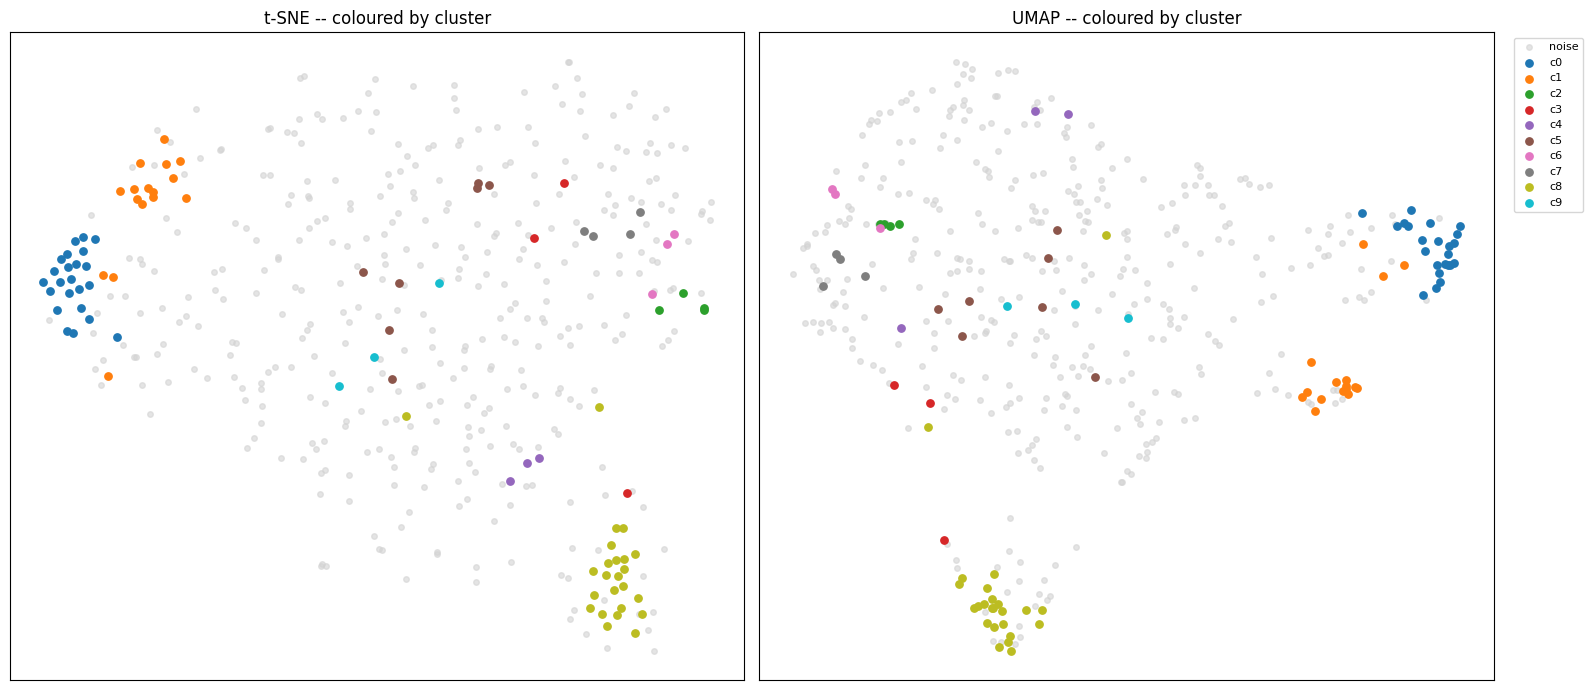

In [8]:
proj = pd.read_csv('data/model_input/latent_projections.csv', index_col=0).reindex(tickers)
ids = sorted(set(labels) - {-1})
colors = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (xc, yc, t) in zip(axes, [('tsne_x', 'tsne_y', 't-SNE'), ('umap_x', 'umap_y', 'UMAP')]):
    m = labels == -1
    ax.scatter(proj[xc][m], proj[yc][m], s=16, c='lightgrey', alpha=0.6, label='noise')
    for i, c in enumerate(ids):
        m = labels == c
        ax.scatter(proj[xc][m], proj[yc][m], s=28, c=[colors[i % 10]], label=f'c{c}')
    ax.set_title(f'{t} -- coloured by cluster'); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## Stability check — are these groups real, or a fluke of this exact set of stocks?

This is the key "how do we know the groups are real?" test. We **redo the grouping 100 times, each time on a random 90% of the stocks**, and ask how closely each redo matches the original grouping. The match score runs from 1 (identical grouping) down to 0 (no better than random); its standard name is the **Adjusted Rand Index (ARI)**.

**In plain terms.** If the groups reflect real structure, leaving out a random tenth of the stocks should not change who lands with whom — the match score stays high. If a group only existed because of a few specific stocks, the score drops. We report the average match score, plus a per-group score (how often each group's members stay together) so we can drop any shaky group before Phase 4.

**Why it matters.** We are about to build the whole trading strategy on these groups. A group that only exists in this one snapshot would hand us pairs that fall apart on new data — the stability score is our guard against that.

In [9]:
def fit_labels(X):
    return hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, metric='euclidean',
                           cluster_selection_method='leaf').fit_predict(X)

N_BOOT, FRAC = 100, 0.9
rng = np.random.default_rng(42)
n = len(Z_aug)
aris = []
co = np.zeros((n, n)); cnt = np.zeros((n, n))
for _ in range(N_BOOT):
    idx = np.sort(rng.choice(n, int(FRAC * n), replace=False))
    lbl_b = fit_labels(Z_aug[idx])
    aris.append(adjusted_rand_score(labels[idx], lbl_b))
    cnt[np.ix_(idx, idx)] += 1
    for c in set(lbl_b) - {-1}:
        mem = idx[lbl_b == c]
        co[np.ix_(mem, mem)] += 1
aris = np.array(aris)
freq = np.divide(co, cnt, out=np.zeros_like(co), where=cnt > 0)
print(f'Bootstrap ARI ({N_BOOT}x, {int(FRAC * 100)}% assets): {aris.mean():.3f} +/- {aris.std():.3f}  [min {aris.min():.3f}, max {aris.max():.3f}]')

Bootstrap ARI (100x, 90% assets): 0.859 +/- 0.059  [min 0.635, max 0.949]


### Per-group stability and the final decision

For each group, we score how often its members stayed together across the 100 redos (1 = always together). We keep a group as **stable** if that score is at least 0.5, and only stable groups go forward to Phase 4.

**How to read the two charts below:**
- **Left** — the spread of match scores across the 100 redos; bunched up near 1 (the dashed line marks the average) means the whole grouping is reliable.
- **Right** — each group's own stability score; green bars clear the 0.5 line (kept), red bars fall short (dropped).

 cluster  size  persistence  mean_intra_dist                                                            top_sectors  stability  stable
       0    23        0.227            3.120                                                         Utilities (23)      0.997    True
       8    24        0.155            2.814                          Financials (22); Unknown (1); Industrials (1)      0.879    True
       2     4        0.044            2.668                            Industrials (2); Consumer Discretionary (2)      0.789    True
       1    16        0.042            3.927                  Real Estate (13); Consumer Staples (2); Utilities (1)      0.816    True
       3     3        0.034            2.804                                          Financials (2); Materials (1)      0.925    True
       9     3        0.029            2.586                                                        Industrials (3)      0.996    True
       7     4        0.012            3.072 Informatio

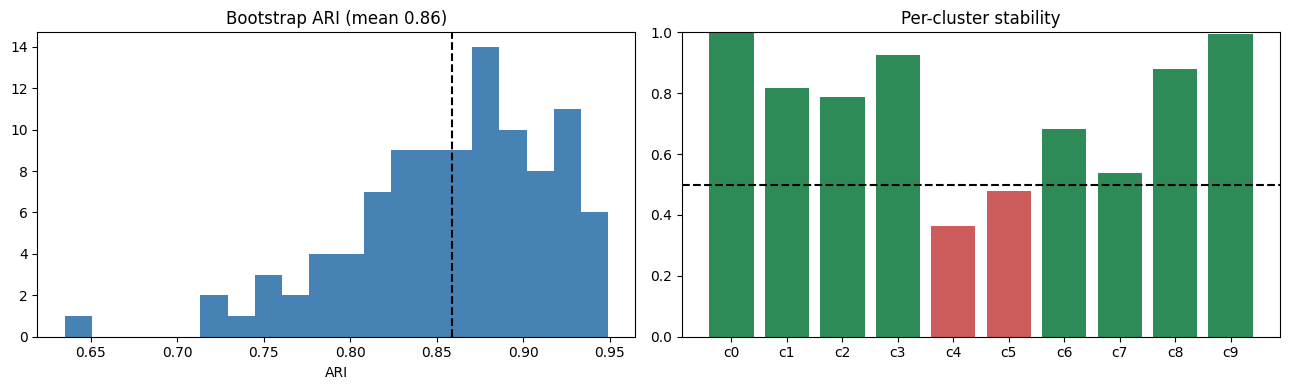

In [10]:
stab = {}
for c in sorted(set(labels) - {-1}):
    mem = np.where(labels == c)[0]
    sub = freq[np.ix_(mem, mem)]
    stab[c] = round(float(sub[np.triu_indices_from(sub, 1)].mean()), 3)
diag['stability'] = diag.cluster.map(stab)
diag['stable'] = diag.stability >= 0.5
print(diag.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(aris, bins=20, color='steelblue'); ax[0].axvline(aris.mean(), color='k', ls='--')
ax[0].set_title(f'Bootstrap ARI (mean {aris.mean():.2f})'); ax[0].set_xlabel('ARI')
ax[1].bar([f'c{c}' for c in stab], list(stab.values()),
          color=['seagreen' if v >= 0.5 else 'indianred' for v in stab.values()])
ax[1].axhline(0.5, color='k', ls='--'); ax[1].set_ylim(0, 1); ax[1].set_title('Per-cluster stability')
plt.tight_layout(); plt.show()

## Save the results for Phase 4

- **cluster_labels.npy** — which group each stock belongs to (−1 = leftover), in the same order as the ticker list.
- **cluster_assignments.csv** — stock, its group, how strongly it belongs, and its industry.
- **cluster_diagnostics.csv** — per-group size, robustness, tightness, industries, stability score and the keep/drop flag.
- **cluster_stability.csv** — the overall match-score summary.
- **latent_profiles_aug.npy** — the rescaled fingerprints the grouping was built on.

Only stocks in a kept (stable) group move on to Phase 4.

In [11]:
np.save('data/model_input/latent_profiles_aug.npy', Z_aug)
np.save('data/model_input/cluster_labels.npy', labels)
assign.to_csv('data/model_input/cluster_assignments.csv')
diag.to_csv('data/model_input/cluster_diagnostics.csv', index=False)
pd.DataFrame([{'ari_mean': aris.mean(), 'ari_std': aris.std(),
               'ari_min': aris.min(), 'ari_max': aris.max(), 'n_boot': N_BOOT}]
            ).to_csv('data/model_input/cluster_stability.csv', index=False)
stable_ids = [c for c in stab if stab[c] >= 0.5]
stable_assets = assign[assign.cluster.isin(stable_ids)].index.tolist()
print(f'Stable clusters: {stable_ids}')
print(f'Assets flowing into Phase 4: {len(stable_assets)}')

Stable clusters: [0, 1, 2, 3, 6, 7, 8, 9]
Assets flowing into Phase 4: 80
